In [1]:
import numpy as np
import matplotlib.pyplot as plt
from CIDER import response_from_all_injections_and_CO2,AOD_from_injection, pattern_from_all_injections_and_CO2
from Toolbox import global_mean, lat_band_mean, stack_and_zoh_injections
import CIDER

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import TwoSlopeNorm
import xarray as xr
import os

import xesmf as xe
import pandas as pd

plt.rcParams.update({'font.size': 13})

In [2]:
#define regridding function 

def regrid(in_dataset, target_dataarray): 
    regridder = xe.Regridder(in_dataset, target_dataarray, 'conservative', periodic=False)
    regridded_dataset = regridder(in_dataset)
    return regridded_dataset


# Restart here 

In [3]:
run load_all_other_variables.py

In [4]:
print(model) # to check which version is activated

CESM


In [5]:
# set number of years

total_years = 35
years_represented_by_array_element = 5 # 1/ ArrayLength 

In [6]:
# no injection scenarios

no_injection = np.zeros((total_years*12, 7))
no_injection_and_CO2 = np.concatenate((no_injection,CO2_forcing_SSP245_month[0:total_years*12].reshape(total_years*12, 1)),axis=1)

SSP245_T_response = response_from_all_injections_and_CO2(no_injection_and_CO2, param_AOD_all, param_T_all)
SSP245_T_pattern = pattern_from_all_injections_and_CO2(no_injection_and_CO2, param_AOD_all, param_T_all, all_T_patterns_scaled)

s245_name = 'SSP245'

# Defining scenarios 

In [7]:
end_yr = 2070
start_yr = 2035
yrs_per_cycle = 5

n_yrs = end_yr - start_yr

if n_yrs % yrs_per_cycle != 0:
    raise ValueError(f"Number of years ({n_yrs}) is not a whole number of cycles ({yrs_per_cycle}-year).")

n_cycles = n_yrs / yrs_per_cycle


inj = [12,12,12,12,12,12,12]  # to check against ukesm model
inj_zeros = [0,0,0,0,0,0,0]

#these are Tg/yr, each number in array corresponding to number of years defined above

In [95]:
# 1 

i_60N = np.array(inj)
i_60N_a1 = i_60N

i_30N, i_15N, i_0NS, i_15S, i_30S, i_60S = inj_zeros,inj_zeros,inj_zeros,inj_zeros,inj_zeros,inj_zeros 


i_scen1 = stack_and_zoh_injections((i_60N, i_30N, i_15N, i_0NS, i_15S, i_30S, i_60S),years_represented_by_array_element*12)
all_injection_and_CO2_scen1 = np.concatenate((i_scen1,CO2_forcing_SSP245_month[0:total_years*12].reshape(total_years*12, 1)),axis=1)

In [96]:
scen1_pattern = pattern_from_all_injections_and_CO2(all_injection_and_CO2_scen1, param_AOD_all, param_T_all, all_T_patterns_scaled)
scen1_response = response_from_all_injections_and_CO2(all_injection_and_CO2_scen1, param_AOD_all, param_T_all)


In [97]:
# response months into years

response_reshaped = scen1_response.reshape(35,12)
rr_mean = response_reshaped.mean(axis = -1)


In [98]:
# creating coordinates 

lon = np.linspace(0, 360, 288, endpoint=False)
lat = np.linspace(-90, 90, 192)
years_2035_2100 = np.arange(2035,2100,1)
years_1855_2095 = np.arange(1855,2096,1)
years_2035_2095 = np.arange(2035,2096,1)

lat2d, lon2d = np.meshgrid(lat, lon)

lat2d_NH = lat2d[:, 96:] 
lon2d_NH = lon2d[:, 96:] 

lat2d_SH = lat2d[:, :96] 
lon2d_SH = lon2d[:, :96] 

weights = np.cos(np.deg2rad(lat))
weights_NH = weights[96:] 
weights_SH = weights[:96] 

In [99]:
# creating NH, SH, IHTD 

# =============== scen ===============
SAI_pattern_reshaped = scen1_pattern.reshape(288, 192, total_years, 12) # split inot years and months
SAI_pat = SAI_pattern_reshaped.mean(axis=-1)   # avg over years

SAI_NH_pat = SAI_pat[:, 96: , :]  # isolate NH   # cause lats are from -90 to 90
SAI_SH_pat = SAI_pat[:, :96 , :]  # isolate SH

SAI_NH_avglat = np.average(SAI_NH_pat, weights = weights_NH, axis = 1)
SAI_NH = np.average(SAI_NH_avglat, axis = 0)

SAI_SH_avglat = np.average(SAI_SH_pat, weights = weights_SH, axis = 1)
SAI_SH = np.average(SAI_SH_avglat, axis = 0)

SAI_ITD = SAI_NH - SAI_SH

# ================== ssp245 ===============
S245_pattern_reshaped = SSP245_T_pattern.reshape(288, 192, total_years, 12) # split inot years and months
S245_pat = S245_pattern_reshaped.mean(axis=-1)   # avg over years

S245_NH_pat = S245_pat[:, 96: , :]  # isolate NH   # cause lats are from -90 to 90
S245_SH_pat = S245_pat[:, :96 , :]  # isolate SH

S245_NH_avglat = np.average(S245_NH_pat, weights = weights_NH, axis = 1)
S245_NH = np.average(S245_NH_avglat, axis = 0)

S245_SH_avglat = np.average(S245_SH_pat, weights = weights_SH, axis = 1)
S245_SH = np.average(S245_SH_avglat, axis = 0)

S245_ITD = S245_NH - S245_SH


In [100]:
if model == 'UKESM':
    IHTD_UKESM_SSP, NH_UKESM_SSP, SH_UKESM_SSP =  S245_ITD, S245_NH, S245_SH
    IHTD_UKESM_SAI, NH_UKESM_SAI, SH_UKESM_SAI, pat_UKESM_SAI = SAI_ITD, SAI_NH, SAI_SH, scen1_pattern
elif model == 'CESM':
    IHTD_CESM_SSP, NH_CESM_SSP, SH_CESM_SSP = S245_ITD, S245_NH, S245_SH
    IHTD_CESM_SAI, NH_CESM_SAI, SH_CESM_SAI, pat_CESM_SAI =  SAI_ITD, SAI_NH, SAI_SH, scen1_pattern


# !!!  Stop here and change model !!!

## rerun from beginning to get both UKESM and CESM data defined. 
## after running from beginning for each model, continue down

# Loading UKESM, CESM validation datasets

In [102]:
def get_ITD_CESMcontrol(hist):
    weights = np.cos(np.deg2rad(hist.lat))
    NH = hist.sel(lat = slice(0,90)).weighted(weights).mean(dim=['lon', 'lat'])
    SH = hist.sel(lat = slice(-90,0)).weighted(weights).mean(dim=['lon', 'lat'])
    ITD = NH-SH
    GMT =  (NH+SH) / 2
    return ITD, GMT #, weights, NH, SH, GMT

def get_ITD_UKESMcontrol(hist):
    weights = np.cos(np.deg2rad(hist.latitude))
    NH = hist.sel(latitude = slice(0,90)).weighted(weights).mean(dim=['longitude', 'latitude'])
    SH = hist.sel(latitude = slice(-90,0)).weighted(weights).mean(dim=['longitude', 'latitude'])
    ITD = NH-SH
    GMT =  (NH+SH) / 2
    return ITD, GMT #, weights, NH, SH, GMT

In [149]:
valid_UKESM = xr.open_dataset('PD_UKESMctrl.nc')
valid_UKESM = valid_UKESM.groupby('time.year').mean('time') #.rolling(year=10, center=True).mean().dropna("year")
itd_valid_UKESM, gmt_valid_UKESM = get_ITD_UKESMcontrol(valid_UKESM.tas)
itd_valid_UKESM_10y = itd_valid_UKESM.rolling(year=10, center=True).mean().dropna("year")
gmt_valid_UKESM_10y = gmt_valid_UKESM.rolling(year=10, center=True).mean().dropna("year")

valid_CESM = xr.open_dataset('PD_CESM_valid.nc')
valid_CESM = valid_CESM.groupby('time.year').mean('time') #.rolling(year=10, center=True).mean().dropna("year")
itd_valid_CESM, gmt_valid_CESM = get_ITD_CESMcontrol(valid_CESM.TREFHT)
itd_valid_CESM_10y = itd_valid_CESM.rolling(year=10, center=True).mean().dropna("year")
gmt_valid_CESM_10y = gmt_valid_CESM.rolling(year=10, center=True).mean().dropna("year")


/tmp/ipykernel_1235/3910264435.py:1: FutureWarning: In a future version, xarray will not decode timedelta values based on the presence of a timedelta-like units attribute by default. Instead it will rely on the presence of a timedelta64 dtype attribute, which is now xarray's default way of encoding timedelta64 values. To continue decoding timedeltas based on the presence of a timedelta-like units attribute, users will need to explicitly opt-in by passing True or CFTimedeltaCoder(decode_via_units=True) to decode_timedelta. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  valid_UKESM = xr.open_dataset('PD_UKESMctrl.nc')


# Getting model ssp245

In [222]:
itd_ssp_UKESM_yrly = xr.open_dataset('PD_extra2plot/UKESM_ens_members_ihtd.nc')
itd_ssp_UKESM = itd_ssp_UKESM_yrly.rolling(year=10, center=True).mean().sel(year = slice(2035,2069))
gmt_ssp_UKESM_yrly = xr.open_dataset('PD_extra2plot/UKESM_ens_members_gmt.nc')
gmt_ssp_UKESM = gmt_ssp_UKESM_yrly.rolling(year=10, center=True).mean().sel(year = slice(2035,2069))

itd_ssp_CESM_yrly = xr.open_dataset('PD_extra2plot/CESM_ens_members.nc')
itd_ssp_CESM = itd_ssp_CESM_yrly.rolling(year=10, center=True).mean().sel(year = slice(2035,2069))
gmt_ssp_CESM_yrly = xr.open_dataset('PD_extra2plot/CESM_ens_members_gmt.nc')
gmt_ssp_CESM = gmt_ssp_CESM_yrly.rolling(year=10, center=True).mean().sel(year = slice(2035,2069))


# Calculations

In [224]:
def get_diff(ssp, sai):
    return sai - ssp

In [225]:
# get difference between ssp and sai in UKESM, CESM

GMT_UKESM_SSP_cider = ( NH_UKESM_SSP + SH_UKESM_SSP ) / 2
GMT_CESM_SSP_cider = ( NH_CESM_SSP + SH_CESM_SSP ) / 2

GMT_UKESM_SAI_cider = ( NH_UKESM_SAI + SH_UKESM_SAI ) / 2
GMT_CESM_SAI_cider = ( NH_CESM_SAI + SH_CESM_SAI ) / 2

gmt_UKESM_diff_cider = GMT_UKESM_SAI - GMT_UKESM_SSP
gmt_CESM_diff_cider = GMT_CESM_SAI - GMT_CESM_SSP
itd_UKESM_diff_cider = IHTD_UKESM_SAI - IHTD_UKESM_SSP
itd_CESM_diff_cider = IHTD_CESM_SAI - IHTD_CESM_SSP


In [226]:
itd_ssp_UKESM_ensmean = itd_ssp_UKESM.mean(dim = 'Ensemble_member').tas
itd_ssp_CESM_ensmean = itd_ssp_CESM.mean(dim = 'Ensemble_member').tas
gmt_ssp_UKESM_ensmean = gmt_ssp_UKESM.mean(dim = 'Ensemble_member').tas
gmt_ssp_CESM_ensmean = gmt_ssp_CESM.mean(dim = 'Ensemble_member').tas

In [227]:
# imposing difference on ssp 

itd_UKESM_imposed = itd_ssp_UKESM_ensmean + itd_UKESM_diff_cider
itd_CESM_imposed = itd_ssp_CESM_ensmean + itd_CESM_diff_cider
gmt_UKESM_imposed = gmt_ssp_UKESM_ensmean + gmt_UKESM_diff_cider
gmt_CESM_imposed = gmt_ssp_CESM_ensmean + gmt_CESM_diff_cider


In [237]:
# getting percentiles 

UK_gmt_p05 = np.percentile(gmt_ssp_UKESM_yrly.sel(year = slice(2035,2069)).tas, 5, axis=0)
UK_gmt_p95 = np.percentile(gmt_ssp_UKESM_yrly.sel(year = slice(2035,2069)).tas, 95, axis=0)
UK_itd_p05 = np.percentile(itd_ssp_UKESM_yrly.sel(year = slice(2035,2069)).tas, 5, axis=0) 
UK_itd_p95 = np.percentile(itd_ssp_UKESM_yrly.sel(year = slice(2035,2069)).tas, 95, axis=0) 

UK_gmt_p05_imp = UK_gmt_p05 + gmt_UKESM_diff_cider
UK_gmt_p95_imp = UK_gmt_p95 + gmt_UKESM_diff_cider
UK_itd_p05_imp = UK_itd_p05 + itd_UKESM_diff_cider
UK_itd_p95_imp =UK_itd_p95 + itd_UKESM_diff_cider

C_gmt_p05 = np.percentile(gmt_ssp_CESM_yrly.sel(year = slice(2035,2069)).tas, 5, axis=0)
C_gmt_p95 = np.percentile(gmt_ssp_CESM_yrly.sel(year = slice(2035,2069)).tas, 95, axis=0) 
C_itd_p05 = np.percentile(itd_ssp_CESM_yrly.sel(year = slice(2035,2069)).tas, 5, axis=0)
C_itd_p95 = np.percentile(itd_ssp_CESM_yrly.sel(year = slice(2035,2069)).tas, 95, axis=0) 

C_gmt_p05_imp = C_gmt_p05 + gmt_CESM_diff_cider
C_gmt_p95_imp = C_gmt_p95 + gmt_CESM_diff_cider
C_itd_p05_imp = C_itd_p05 + itd_CESM_diff_cider
C_itd_p95_imp = C_itd_p95 + itd_CESM_diff_cider

# Validation figure

In [279]:
K = 273.1

UKESM_dict = {"gmt_model_ensmean": gmt_ssp_UKESM_ensmean-K, 
            'gmt_imposed': gmt_UKESM_imposed-K,
            'gmt_valid': gmt_valid_UKESM-K,
            'gmt_valid_10y': gmt_valid_UKESM_10y-K,
            'gmt_05_imp':UK_gmt_p05_imp-K,
            'gmt_95_imp':UK_gmt_p95_imp-K,
            'gmt_05':UK_gmt_p05-K,
            'gmt_95':UK_gmt_p95-K,
            "itd_model_ensmean": itd_ssp_UKESM_ensmean, 
            'itd_imposed': itd_UKESM_imposed,
            'itd_valid': itd_valid_UKESM,
            'itd_valid_10y': itd_valid_UKESM_10y,
            'itd_05_imp':UK_itd_p05_imp,
            'itd_95_imp':UK_itd_p95_imp,
            'itd_05':UK_itd_p05,
            'itd_95':UK_itd_p95,
           }

CESM_dict = {"gmt_model_ensmean": gmt_ssp_CESM_ensmean-K, 
            'gmt_imposed': gmt_CESM_imposed-K,
            'gmt_valid': gmt_valid_CESM[:-1]-K,
            'gmt_valid_10y': gmt_valid_CESM_10y[:-1]-K,
            'gmt_05_imp':C_gmt_p05_imp-K,
            'gmt_95_imp':C_gmt_p95_imp-K,
            'gmt_05':C_gmt_p05-K,
            'gmt_95':C_gmt_p95-K,
            "itd_model_ensmean": itd_ssp_CESM_ensmean, 
            'itd_imposed': itd_CESM_imposed,
            'itd_valid': itd_valid_CESM[:-1],
            'itd_valid_10y': itd_valid_CESM_10y[:-1],
            'itd_05':C_itd_p05,
            'itd_95':C_itd_p95,
            'itd_05_imp':C_itd_p05_imp,
            'itd_95_imp':C_itd_p95_imp,
           }


In [303]:
def plot_valid(mod_dict, model_name):
    '''
    mod_dict = {"gmt_model_ensmean": gmt_ssp_CESM_ensmean, 
    '''
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
    varbs = ['gmt', 'itd']
    K = 273.1
    for i in range(len(axs)):
        ax = axs[i]
        var = varbs[i]
        ax.plot(mod_dict[f"{var}_model_ensmean"].year, mod_dict[f"{var}_model_ensmean"], c = 'blue', lw = 2, label = 'Ens-mean model SSP245')
        ax.plot(mod_dict[f'{var}_imposed'].year, mod_dict[f'{var}_imposed'], c = 'blue', ls = ':', lw = 2, label = 'Ens-mean + imposed CIDER change')
        ax.fill_between(np.arange(2035,2070), mod_dict[f'{var}_05'],mod_dict[f'{var}_95'], color = 'blue', alpha = 0.1, label = '5-95% int')
        ax.fill_between(np.arange(2035,2070), mod_dict[f'{var}_05_imp'],mod_dict[f'{var}_95_imp'], color = 'blue', alpha = 0.1)
        ax.plot(mod_dict[f'{var}_valid'].year, mod_dict[f'{var}_valid'],  c = 'hotpink', lw = 1, label = f'control: {model_name} 60N 12Tg SAI, yrly' )
        ax.plot(mod_dict[f'{var}_valid_10y'].year, mod_dict[f'{var}_valid_10y'],  c = 'hotpink', lw = 2, label = f'control: {model_name} 60N 12Tg SAI, 10yr-mean')
        ax.set_xlabel('Year')
        
        ax.grid(alpha=0.3)
    axs[0].legend(fontsize=8)
    fig.suptitle(model_name)
    axs[1].set_ylabel('IHTD ($^\circ$C)')
    axs[0].set_ylabel('GMT ($^\circ$C)')
    plt.tight_layout()
    plt.savefig(f'PD_figures/valid_{model_name}', dpi = 300)

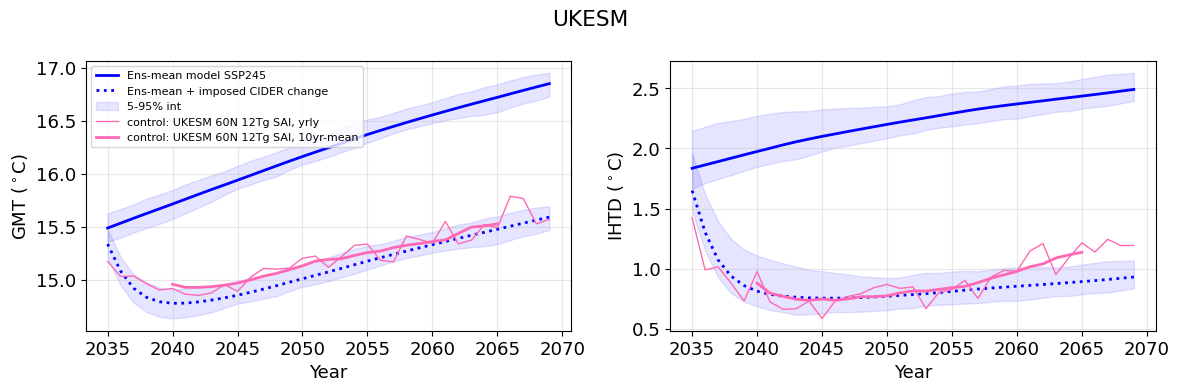

In [304]:
plot_valid(UKESM_dict, 'UKESM')


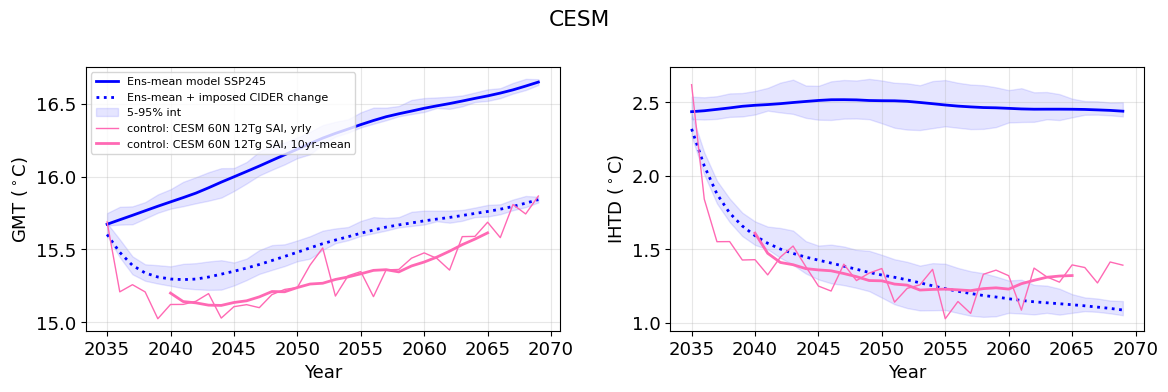

In [305]:
plot_valid(CESM_dict, 'CESM')

In [306]:
var = 'gmt'
mod_dict[f"{var}_model_ensmean"][-1].values

array(289.94948307)

In [267]:
def plot_valid_ciderssp(mod_dict, model_name):
    '''
    mod_dict = {"gmt_model_ensmean": gmt_ssp_CESM_ensmean, 
    '''
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12, 4))
    varbs = ['gmt', 'itd']
    for i in range(len(axs)):
        var = varbs[i]
        orig = mod_dict[f"{var}_model_ensmean"][1].values
        ax = axs[i]
        ax.plot(mod_dict[f"{var}_model_ensmean"].year, mod_dict[f"{var}_model_ensmean"], c = 'blue', lw = 2, label = 'Ens-mean model SSP245')
        ax.plot(mod_dict[f'{var}_imposed'].year, mod_dict[f'{var}_imposed'], c = 'blue', ls = ':', lw = 2, label = 'Ens-mean + imposed CIDER change')
        ax.plot(mod_dict[f'{var}_valid'].year, mod_dict[f'{var}_valid'],  c = 'hotpink', lw = 1, label = f'control: {model_name} 60N 12Tg SAI, yrly' )
        ax.plot(mod_dict[f'{var}_valid_10y'].year, mod_dict[f'{var}_valid_10y'],  c = 'hotpink', lw = 2, label = f'control: {model_name} 60N 12Tg SAI, 10yr-mean')
        ax.fill_between(np.arange(2035,2070), mod_dict[f'{var}_05'],mod_dict[f'{var}_95'], color = 'blue', alpha = 0.2, label = '5-95% int')
        ax.fill_between(np.arange(2035,2070), mod_dict[f'{var}_05_imp'],mod_dict[f'{var}_95_imp'], color = 'blue', alpha = 0.2)
        ax.set_xlabel('Year')
        ax.set_title(model_name)
      #  ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

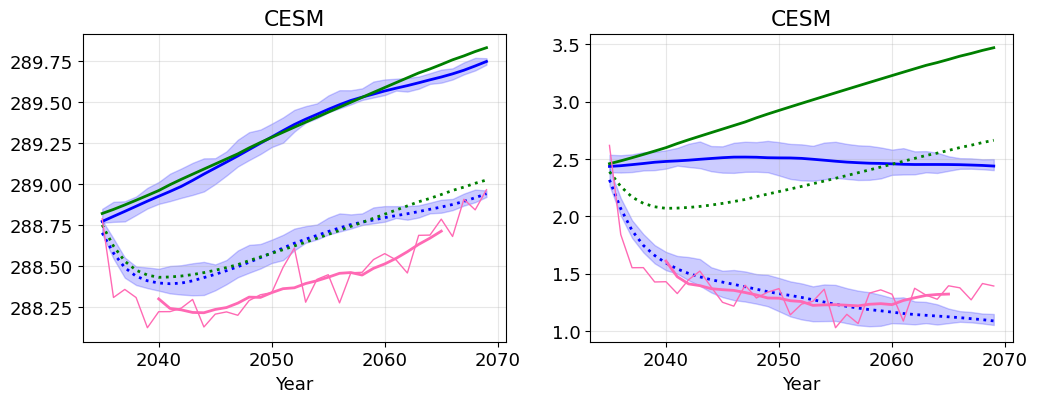

In [268]:
plot_valid_ciderssp(CESM_dict, 'CESM')